In [1]:
import matplotlib.pyplot as plt
import nivapy3 as nivapy
import numpy as np
import pandas as pd
from sqlalchemy import text

plt.style.use("ggplot")

In [2]:
eng = nivapy.da.connect()

Username:  ········
Password:  ········


Connection successful.


# Check RESA2 UV absorbance calculations

A quick notebook to reproduce the RESA2 absorbance workflow.

## 1. Functions to reproduce the RESA workflow

Raw absorbance values are processed by subtracting the blank values, multiplying by the dilution, and dividing by the cuvette length.

In [3]:
def read_uv_abs(fpath):
    """Read a raw UV absorbance file.

    Args
        fpath: Str. Path to raw file

    Returns
        Dataframe.
    """
    df = pd.read_csv(
        fpath,
        sep="\s+",
        skiprows=86,
        header=None,
        names=["wavelength", "value"],
        index_col=0,
    )
    df.index = df.index.astype(int)

    if len(df) != 701:
        msg = f"ERROR: File '{fpath}' contains {len(df)} rows (expected 701)."
        raise ValueError(msg)

    return df


def correct_values(raw_abs_df, blank_df, cuvette_len_cm, dilution):
    """Adjust values in 'raw_abs_df' based on 'blank_df' and correct for
       cuvette length and dilution. Also adds water sample and method IDs.

    Args
        raw_abs_df:     Dataframe. Raw UV absorbance values to correct. Must
                        have wavelength as an integer index
        blank_df:       Dataframe. Blank sample for this run. Must have
                        wavelength as an integer index
        cuvette_len_cm: Int. Length of cuvette used (in cm)
        dilution:       Int. Dilution factor used for sample (dimensionless)

    Returns
        Dataframe.
    """
    df = raw_abs_df.join(blank_df, how="inner", rsuffix="_blank")

    if len(df) != 701:
        msg = f"ERROR: Joined dataframe contains {len(df)} rows (expected 701)."
        raise ValueError(msg)

    df["value"] = (df["value"] - df["value_blank"]) * dilution / cuvette_len_cm
    df = df[["value"]].reset_index()

    return df

## 2. Test data

Use the same test data recently sent o Liza.

In [4]:
# Dict mapping Labware ID to metadata:
#     dict[labware_id] => [resa_water_sample_id, dilution, cuvette_length]
data = {"12071": [960808, 2, 5], "25-13349": [960924, 1, 5]}

In [5]:
df_list = []
for lw_id, (ws_id, dil, clen) in data.items():
    # Get the processed data from RESA2 for comparison
    sql = text(
        """
    SELECT wavelength, value AS resa_abs_per_cm FROM resa2.absorbance_spectras
    WHERE water_sample_id = :ws_id
    """
    )
    resa_df = pd.read_sql(sql, eng, params={"ws_id": ws_id})

    # Process the raw data using functions defined above
    raw_path = f"/home/jovyan/shared/common/JES/compare_resa_abs/{lw_id}/{lw_id}.SP"
    bl_path = f"/home/jovyan/shared/common/JES/compare_resa_abs/{lw_id}/BLANK.SP"
    raw_df = read_uv_abs(raw_path)
    bl_df = read_uv_abs(bl_path)
    new_df = correct_values(raw_df, bl_df, clen, dil).rename(
        columns={"value": "new_abs_per_cm"}
    )

    # Combine
    df = pd.merge(resa_df, new_df, how="inner", on="wavelength")
    df["lw_id"] = lw_id
    df_list.append(df)

df = pd.concat(df_list, axis="rows")
df = df[["lw_id", "wavelength", "resa_abs_per_cm", "new_abs_per_cm"]]
df.head()

,lw_id,wavelength,resa_abs_per_cm,new_abs_per_cm
0,12071,200,1.145716,1.145716
1,12071,201,1.135784,1.135784
2,12071,202,1.129108,1.129108
3,12071,203,1.135936,1.135936
4,12071,204,1.120496,1.120496


## 3. Compare values

In [6]:
# Check whether values calculated in this notebook are the same as those in RESA to within 5 d.p.
tol = 1e-5
same = np.allclose(
    df["resa_abs_per_cm"].to_numpy(),
    df["new_abs_per_cm"].to_numpy(),
    rtol=0,
    atol=tol,
    equal_nan=True,
)
if same:
    print(f"Values are the same to within {tol} per cm.")
else:
    print("Values are not the same.")

Values are the same to within 1e-05 per cm.


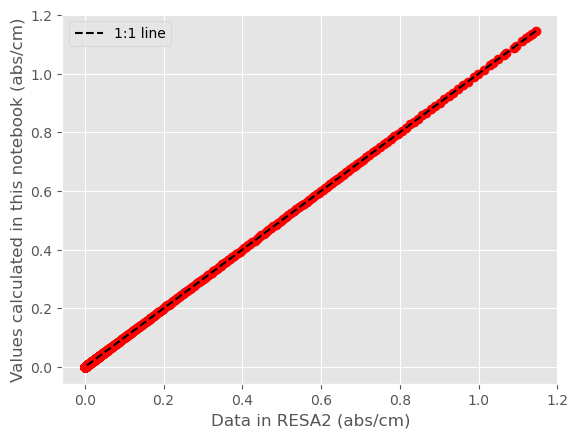

In [7]:
# Plot
plt.plot(df["resa_abs_per_cm"], df["new_abs_per_cm"], "ro")
plt.plot(df["resa_abs_per_cm"], df["resa_abs_per_cm"], "k--", label="1:1 line")
plt.xlabel('Data in RESA2 (abs/cm)')
plt.ylabel('Values calculated in this notebook (abs/cm)')
plt.legend()

In [8]:
del df["new_abs_per_cm"]
df.to_excel(r"/home/jovyan/shared/common/JES/compare_resa_abs/resa_abs_example_data.xlsx", index=False)